<h1 align = 'center'>Practical 9: PMF, PDF, and CDF (Questions)</h1>

### Import necessary libraries, load the 'students.csv' dataset, display a data sample, determine dataset dimensions, and view the summary statistics for both quantitative and qualitative columns.

In [28]:
#import the necessary lib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import binom
import math

In [2]:
#Read and show 'students.csv'
df = pd.read_csv('students.csv')
df.head(5)

,stud.id,name,gender,age,height,weight,religion,nc.score,semester,major,minor,score1,score2,online.tutorial,graduated,salary
0,833917,"Gonzales, Christina",Female,19,160,64.8,Muslim,1.91,1st,Political Science,Social Sciences,NaN,NaN,0,0,NaN
1,898539,"Lozano, T'Hani",Female,19,172,73.0,Other,1.56,2nd,Social Sciences,Mathematics and Statistics,NaN,NaN,0,0,NaN
2,379678,"Williams, Hanh",Female,22,168,70.6,Protestant,1.24,3rd,Social Sciences,Mathematics and Statistics,45.0,46.0,0,0,NaN
3,807564,"Nem, Denzel",Male,19,183,79.7,Other,1.37,2nd,Environmental Sciences,Mathematics and Statistics,NaN,NaN,0,0,NaN
4,383291,"Powell, Heather",Female,21,175,71.4,Catholic,1.46,1st,Environmental Sciences,Mathematics and Statistics,NaN,NaN,0,0,NaN


In [3]:
df.shape

(8239, 16)

In [4]:
#show the summary statistics for qantitative and qualitative columns
df.describe()

,stud.id,age,height,weight,nc.score,score1,score2,online.tutorial,graduated,salary
count,8239.000000,8239.000000,8239.000000,8239.000000,8239.000000,4892.000000,4892.000000,8239.000000,8239.000000,1753.000000
mean,548910.484525,22.541571,171.380750,72.998131,2.166481,68.164963,69.494685,0.386212,0.212769,42522.112364
std,253849.389811,6.065111,11.077529,8.635162,0.811548,14.051762,14.395251,0.486910,0.409290,10333.139906
min,110250.000000,18.000000,135.000000,51.400000,1.000000,30.000000,31.000000,0.000000,0.000000,11444.141650
25%,331222.500000,20.000000,163.000000,66.500000,1.460000,58.000000,59.000000,0.000000,0.000000,35206.541600
50%,545132.000000,21.000000,171.000000,71.800000,2.040000,70.000000,71.000000,0.000000,0.000000,41672.009750
75%,770807.500000,23.000000,180.000000,78.500000,2.780000,78.000000,80.000000,1.000000,0.000000,49372.540910
max,989901.000000,64.000000,206.000000,116.000000,4.000000,97.000000,98.000000,1.000000,1.000000,75596.793440


In [5]:
df.describe(include = 'O')

,name,gender,religion,semester,major,minor
count,8239,8239,8239,8239,8239,8239
unique,8174,2,5,7,6,6
top,"Nguyen, Brandon",Male,Catholic,1st,Environmental Sciences,Mathematics and Statistics
freq,3,4129,2797,1709,1626,1446


### Q1: Draw a histogram of 'weight' and provide a short description of your observations with identifying the distribution.

Text(0.5, 1.0, 'Distribution of Car Weight')

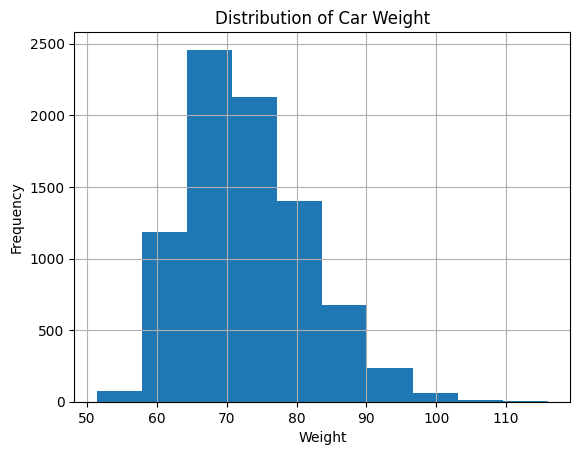

In [6]:
#Draw a histrogram for 'weight'
df['weight'].hist()
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.title('Distribution of Car Weight')

#### Write your short description here: distribution is normal, as it has bell shaped .

### Q2: Calculate the skewness of 'weight' and explain its significance.

In [7]:
df['weight'].skew().item()

0.6510039648535437

#### Explain its significance here: The skewness of the weight column is 0.65, indicating a moderate right skew, which means that while most cars are around the central weight, there are a few heavier cars stretching the distribution to the right.

### Q3: What is the probability that a student's weight is between 70 kg and 80 kg?
Here, you should use the right distribution function and probability function from
scipy.stats

In [15]:
mean = df['weight'].mean()
std =  df['weight'].std()

z1 = (80 - mean)/std
z2 = (70 - mean)/std

prob1 = norm.cdf(z1) - norm.cdf(z2)
prob1.item()

0.42705528013215666

### Q5: What is the probability that a student's weight is greater than 70 Kg ?
Here, you should use the right distribution function and probability function from
scipy.stats

In [16]:
prob2 = 1 - norm.cdf(z2)
prob2.item()

0.6357795821497002

### Q6: A company produces electronic components, and their quality control process involves testing each component for defects. The defect rate for these components is 6%. The company recently received a large order for 300 components. They want to determine the probability of having a certain number of defective components in this order. 
Here, you should use the right distribution function and probability function from scipy.stats.
### Question 6.1: What is the probability that exactly 10 components out of an order of 300 are defective?

In [21]:
prob3 = binom.pmf(10, 300, 0.06)
prob3.item()

0.013620614128121553

### Question 6.2: What is the probability that minimum 10 components out of an order of 300 are defective?

In [23]:
prob4 = 1 - binom.cdf(9, 300, 0.06)
prob4.item()

0.9868069575023568

### Question 6.3: What is the probability that maximum 10 components out of an order of 300 are defective?

In [25]:
prob5 = binom.cdf(10, 300, 0.06)
prob5.item()

0.026813656625764497

### Question 6.3: Calculate the number of components that are likely to be defective and the standard deviation of the defect probabilities for the 300 components.

In [30]:
mean, var = binom.stats(300, 0.06)
print(mean)
print(math.sqrt(std))

18.0
4.113392760240627
